<a href="https://colab.research.google.com/github/dioufabdoulaye910/tb-detection-deep-learning/blob/main/01_EDA_TB_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
data_path = "/content/drive/MyDrive/TB_Chest_Radiography_Database/"

In [3]:
import os
os.listdir(data_path)

['Normal.metadata.xlsx',
 'Tuberculosis.metadata.xlsx',
 'README.md.txt',
 '.DS_Store',
 'Tuberculosis',
 'Normal']

In [4]:
data_path = "/content/drive/MyDrive/TB_Chest_Radiography_Database/"

tb_path = os.path.join(data_path, "Tuberculosis")
normal_path = os.path.join(data_path, "Normal")

In [5]:
print("TB images:", len(os.listdir(tb_path)))
print("Normal images:", len(os.listdir(normal_path)))

TB images: 700
Normal images: 3500


In [6]:
def clean_list(folder):
    return [f for f in os.listdir(folder) if f.endswith(('.png', '.jpg', '.jpeg'))]

tb_images = clean_list(tb_path)
normal_images = clean_list(normal_path)

print(len(tb_images), len(normal_images))

700 3500


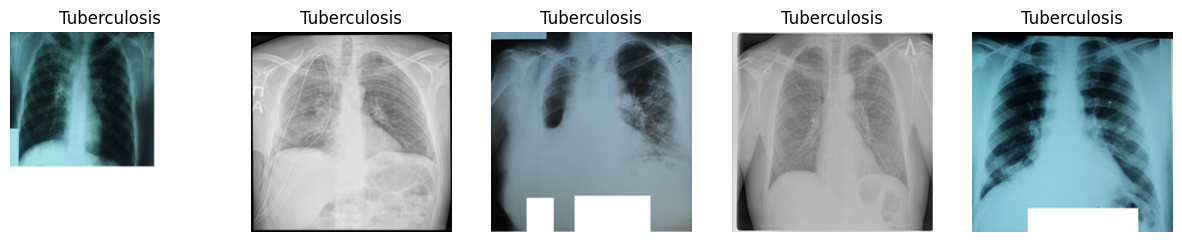

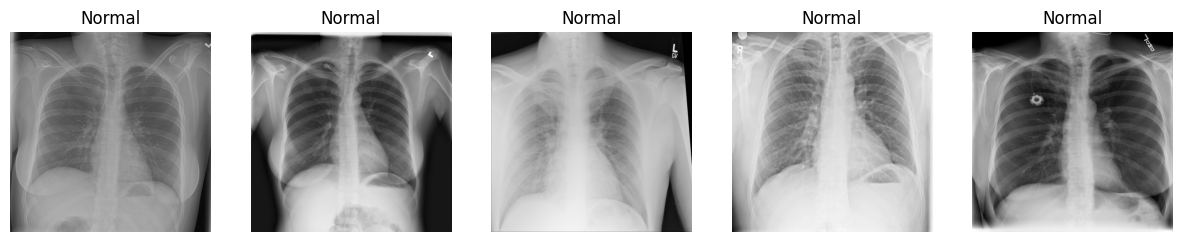

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_images(folder, images, title):
    plt.figure(figsize=(15,5))
    sample = random.sample(images, 5)

    for i, img_name in enumerate(sample):
        img = Image.open(os.path.join(folder, img_name))

        plt.subplot(1,5,i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(title)

    plt.show()

show_images(tb_path, tb_images, "Tuberculosis")
show_images(normal_path, normal_images, "Normal")

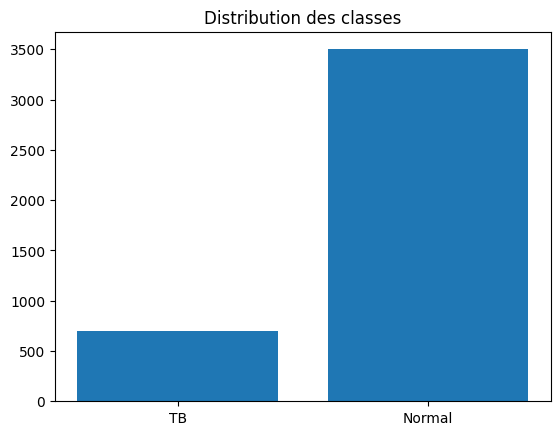

In [8]:
plt.bar(["TB", "Normal"], [len(tb_images), len(normal_images)])
plt.title("Distribution des classes")
plt.show()

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=[0]*3500 + [1]*700
)

print(class_weights)

[0.6 3. ]


In [10]:
from PIL import Image

def check_images(folder):
    corrupted = []
    for img_name in os.listdir(folder):
        try:
            img_path = os.path.join(folder, img_name)
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_name)
    return corrupted

print("Corrupted TB:", check_images(tb_path))
print("Corrupted Normal:", check_images(normal_path))

Corrupted TB: []
Corrupted Normal: []


## Conclusion de l’analyse exploratoire et du nettoyage des données

La phase de nettoyage et d’analyse exploratoire a permis de préparer efficacement le dataset de radiographies pulmonaires pour la tâche de classification de la tuberculose.

###  1. Qualité des données

Le dataset est de bonne qualité :

* Aucune image corrompue n’a été détectée.
* Les fichiers sont correctement structurés en deux classes : **Tuberculosis** et **Normal**.
* Les données sont exploitables directement pour des modèles de Deep Learning.

###  2. Composition du dataset

Le dataset est composé de :

* 700 images de patients atteints de tuberculose
* 3500 images de patients sains (Normal)

Cela montre un **déséquilibre significatif entre les classes**, avec une majorité de cas normaux.

###  3. Implications du déséquilibre

Ce déséquilibre peut entraîner :

* Une tendance du modèle à privilégier la classe majoritaire (Normal)
* Une diminution de la capacité à détecter correctement les cas de tuberculose

Pour corriger ce problème, des techniques adaptées seront utilisées lors de la phase de modélisation :

* Pondération des classes (class weights)
* Data augmentation pour la classe minoritaire

###  4. Nettoyage des données

Les étapes suivantes ont été réalisées :

* Suppression des fichiers non pertinents (.xlsx, .txt, .DS_Store)
* Filtrage des images valides uniquement
* Vérification de l’intégrité des images (aucune image corrompue détectée)

###  5. Préparation pour la modélisation

Le dataset est maintenant prêt pour les prochaines étapes :

* Prétraitement des images (redimensionnement et normalisation)
* Construction d’un modèle de Deep Learning pour la classification

###  Conclusion générale

Cette première phase confirme que le dataset est propre, structuré et exploitable. Les prochaines étapes consisteront à préparer les images et à entraîner des modèles de Deep Learning capables de détecter automatiquement la tuberculose à partir des radiographies pulmonaires.
